## Importation des librairies

In [12]:

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.ensemble import IsolationForest
import pickle


## Visualisation des données

In [13]:
df = pd.read_excel("ICalls dataset.xlsx")
df.head()

,CALL_ID,START_TIMESTAMP,CALL_DURATION_SEC,CALLING_NUMBER_NOR,CALLED_NUMBER_NOR,RELEASE_CALSE_ID,IN_SWITCH_ID,IN_TRUNK_ID,IN_ACCOUNT_ID,IN_SERVICE_LEVEL_ID,...,OUT_ACCOUNT_ID,OUT_SERVICE_LEVEL_ID,OUT_SERVICE_ID,ROUTING_CLASS_ID,ROUTING_DESTINATION_ID,ROUTING_COUNTRY_ID,ORIG_COUNTRY_ID,ANSWERED,COST,REVENUE
0,1000284067810012905,2020-02-02 00:28:10,123,1.304815e+12,1063401614250,144,3,3814,381,8,...,221,0,1,8,1067,146,241,1,0.681010,0.682035
1,1000284067810012912,2020-02-02 00:30:13,1,7.718661e+10,14589732215,144,3,3170,204,8,...,190,0,1,8,272224,67,229,1,0.002583,0.002583
2,1000284067810009861,2020-02-02 00:09:18,33,2.239853e+12,2239769672380,144,3,3170,204,3,...,130,0,1,4,1798,228,228,1,0.003025,0.003025
3,1000284067810012939,2020-02-02 00:29:47,43,2.457868e+13,24578661100030,144,3,3617,249,2,...,256,0,1,2,540,80,80,1,0.007102,0.000000
4,1000284067810012946,2020-02-02 00:28:51,101,1.966744e+12,2238910138380,144,3,1353,234,2,...,370,0,1,2,1778,228,107,1,0.013467,0.012120


## Verification des données manquantes

In [14]:
df.isna().sum()


CALL_ID                    0
START_TIMESTAMP            0
CALL_DURATION_SEC          0
CALLING_NUMBER_NOR        74
CALLED_NUMBER_NOR          8
RELEASE_CALSE_ID           0
IN_SWITCH_ID               0
IN_TRUNK_ID                0
IN_ACCOUNT_ID              0
IN_SERVICE_LEVEL_ID        0
IN_SERVICE_ID              0
OUT_SWITCH_ID              0
OUT_TRUNK_ID               0
OUT_ACCOUNT_ID             0
OUT_SERVICE_LEVEL_ID       0
OUT_SERVICE_ID             0
ROUTING_CLASS_ID           0
ROUTING_DESTINATION_ID     0
ROUTING_COUNTRY_ID         0
ORIG_COUNTRY_ID            0
ANSWERED                   0
COST                       0
REVENUE                    0
dtype: int64

In [15]:
#suppression des lignes avec des valeurs manquantes
#df= df.dropna()

## verification des données redondantes

In [16]:

df.duplicated().value_counts()


df.IN_SWITCH_ID.dtypes

dtype('int64')

## Création de nouvelles variables

In [17]:
# --- Création de caractéristiques pour mieux détecter les anomalies ---
# --- Création de caractéristiques synchronisées ---
df['COST_PER_SEC'] = df['COST'] / (df['CALL_DURATION_SEC'] + 1e-6)
df['WANGIRI_SCORE'] = ((df['ANSWERED'] == 0) & (df['CALL_DURATION_SEC'] <= 5)).astype(int)
df['COST_REVENUE_DIFF'] = df['COST'] - df['REVENUE']

# AJOUT des IDs pour atteindre 8 variables comme dans l'App
features_for_model = [
    'CALL_DURATION_SEC', 
    'ANSWERED', 
    'COST', 
    'REVENUE',
    'COST_PER_SEC',
    'WANGIRI_SCORE',
    'COST_REVENUE_DIFF',
    'IN_SWITCH_ID'  # La 8ème variable
]

df_model = df[features_for_model].fillna(0) # Remplace les vides par 0

# Gestion des valeurs infinis et manquantes
for col in ['COST_PER_SEC']:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)

df_model = df[features_for_model].copy().dropna()
print(f"Dimensions du dataset pour l'entraînement : {df_model.shape}")


Dimensions du dataset pour l'entraînement : (99999, 8)


## Entraînement du modèle Isolation Forest

In [18]:
# --- Entraînement du modèle ---
print("Entraînement du modèle Isolation Forest...")

# 'contamination' : proportion estimée d'anomalies (ex: 0.1%)
model = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
model.fit(df_model)

# Prédiction (1 pour normal, -1 pour anomalie)
df_model['prediction'] = model.predict(df_model)
# Score d'anomalie (plus bas = plus suspect)
df_model['anomaly_score'] = model.decision_function(df_model[features_for_model])

print("Modèle entraîné.")

Entraînement du modèle Isolation Forest...
Modèle entraîné.


## Analyse des résultats

In [19]:
# Statistiques sur les anomalies détectées
print("\n--- Répartition des anomalies ---")
print(df_model['prediction'].value_counts(normalize=True))

# Afficher quelques exemples d'anomalies détectées
print("\n--- Exemple d'appels suspects détectés ---")
display(df_model[df_model['prediction'] == -1].sort_values(by='anomaly_score').head())


--- Répartition des anomalies ---
prediction
 1    0.95015
-1    0.04985
Name: proportion, dtype: float64

--- Exemple d'appels suspects détectés ---


,CALL_DURATION_SEC,ANSWERED,COST,REVENUE,COST_PER_SEC,WANGIRI_SCORE,COST_REVENUE_DIFF,IN_SWITCH_ID,prediction,anomaly_score
10010,4949,1,6.598667,17.321500,0.001333,0,-10.722833,3,-1,-0.236625
90289,4339,1,4.620529,4.772900,0.001065,0,-0.152371,3,-1,-0.226273
29676,3600,1,4.740000,4.860000,0.001317,0,-0.120000,3,-1,-0.223221
90272,2432,1,2.837333,3.019733,0.001167,0,-0.182400,3,-1,-0.219628
32829,3156,1,4.155400,4.260600,0.001317,0,-0.105200,3,-1,-0.219076


## Visualisation des anomalies

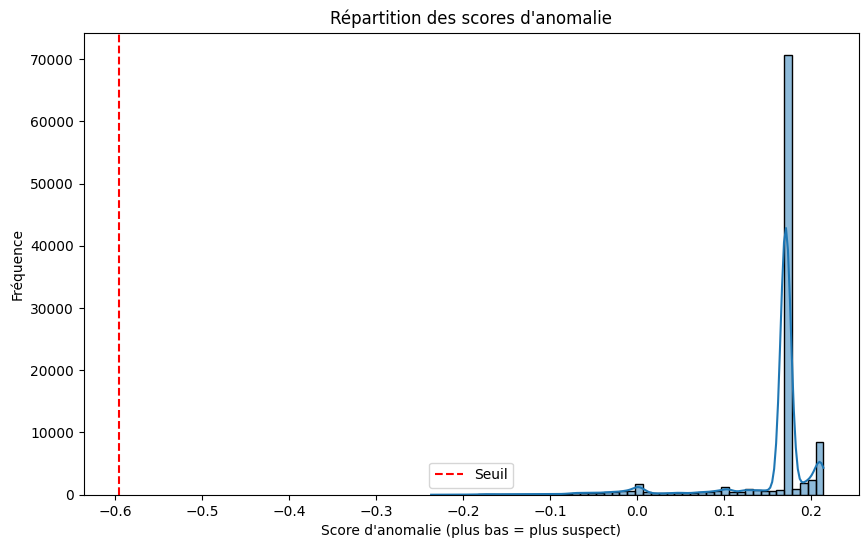

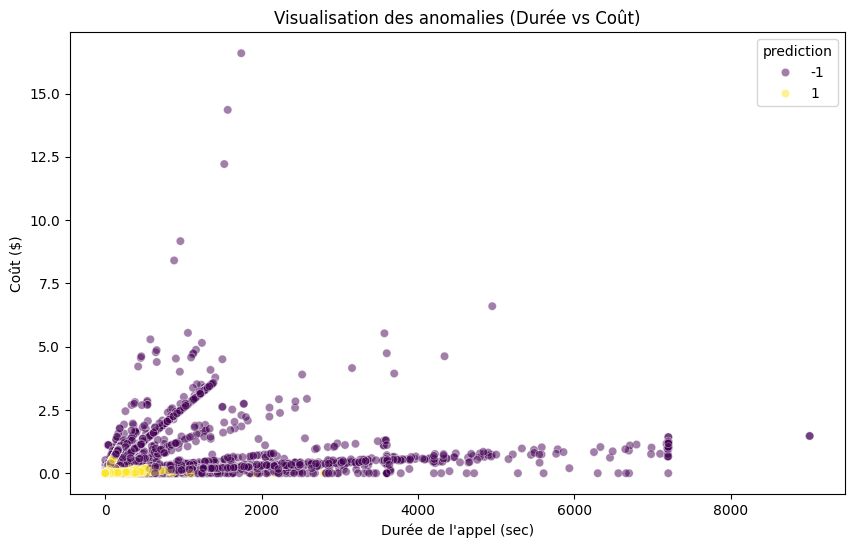

In [20]:
# --- Visualisation 1 : Répartition des scores d'anomalie ---
plt.figure(figsize=(10, 6))
sns.histplot(df_model['anomaly_score'], bins=50, kde=True)
plt.title('Répartition des scores d\'anomalie')
plt.xlabel('Score d\'anomalie (plus bas = plus suspect)')
plt.ylabel('Fréquence')
plt.axvline(x=model.offset_, color='red', linestyle='--', label='Seuil')
plt.legend()
plt.show()

# --- Visualisation 2 : Scatter plot (Durée vs Coût) ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_model, x='CALL_DURATION_SEC', y='COST', hue='prediction', palette='viridis', alpha=0.5)
plt.title('Visualisation des anomalies (Durée vs Coût)')
plt.xlabel('Durée de l\'appel (sec)')
plt.ylabel('Coût ($)')
plt.show()

## Sauvegarde du modèle

In [21]:
# Sauvegarde du modèle entraîné
with open('telecom_fraud_model.pkl', 'wb') as file:
    pickle.dump(model, file)
print("Modèle sauvegardé dans 'telecom_fraud_model.pkl'")

Modèle sauvegardé dans 'telecom_fraud_model.pkl'
